Importing the Necessary Modules

In [40]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as pltS
import numpy as np
from matplotlib import pyplot
import random
import json
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Connecting to the Database

In [41]:
db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'alt_composite_data'

In [42]:
connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)

The DataFrame

In [43]:
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
0,12264,0.2,585.555556,"[-0.007655087658242564, -0.004801041284693981,...","[-3.4469028850348216, -1.8186479959276196, -0....","[0.00768155719670075, 0.007502365114726271, 0....","[0.8160981603606225, 2.6595247369015214, 4.321...","[0.36952611197163027, 0.35252177586629885, 0.3...","[-1.9910019861306951, -1.2195676418990897, -1....","[5.8600367055377624e-05, 2.304999741733603e-05...","[11.881139498861376, 3.3074805330915473, 0.000...","[5.900632096618508e-05, 5.628548231466173e-05,...","[0.6660162073439924, 7.073071826191106, 18.679...","[0.026386343734390753, 0.008731404110774473, 0...","[-0.006247302955291063, -0.012768488059529102,...","[-0.02647758166286781, -0.013644161280614218, ...","[-2.8130111034186402, -4.836739332885881, -0.1...","[0.006268904696932383, 0.019952725607881538, 0...","[[-1.601935810150706], [0.10545334511763048], ..."
1,12265,0.2,585.555556,"[-0.01571843108341197, -0.020300083150291328, ...","[-0.009968412200285881, 4.145152789852208, 8.2...","[-0.0006910519719969889, -0.000790071605603099...","[2.3551285101200956, 2.000501326013423, 1.2223...","[0.5022751624178928, 0.5064484325811198, 0.510...","[0.3677834330261918, 0.5430458851264314, 0.519...","[0.00024706907572397157, 0.0004120933759087419...","[9.93692417948084e-05, 17.182291651219543, 67....","[4.775528280009272e-07, 6.242131419802603e-07,...","[5.546630299180501, 4.002005555381463, 1.49405...","[0.0001566878001812367, -0.0841469463046619, -...","[-0.03701892517890143, -0.04061034326034054, -...","[6.888690908686401e-06, -0.003274967520148703,...","[-0.02347689177352227, 8.292383652627581, 10.0...","[-0.0016275162012248225, -0.001580539294654555...","[[0.7545725874688828], [-0.3944163293216931], ..."
2,12266,0.2,585.555556,"[0.004301376974659637, 0.00866560466106875, 0....","[12.552733914183177, 9.640854502014358, 5.2629...","[0.003971979494105779, 0.005064583974269333, 0...","[-16.430506601311656, -16.32264365725276, -15....","[0.4850690444035489, 0.49444093659124544, 0.51...","[0.5784778843086674, 1.4859866398759078, 2.904...","[1.850184387813209e-05, 7.509270414193645e-05,...","[157.5711287202845, 92.94607552901051, 27.6982...","[1.5776621101596803e-05, 2.565001083242575e-05...","[269.9615471757459, 266.4286959616537, 245.816...","[0.05399404062749666, 0.08354383370934126, 0.0...","[-0.07067380277687513, -0.14144557695725377, -...","[0.04985920170210176, 0.04882691720916427, 0.0...","[-206.2477774414954, -157.36423258780135, -82....","[-0.06526163529817954, -0.0826673994842313, -0...","[[1.0430649512774977], [0.4454969238511131], [..."
3,12267,0.2,585.555556,"[-0.0067244894634242575, -0.009987527677064425...","[-7.693103246824563, -5.0420754532056336, -2.0...","[0.0047108930146879694, 0.004206594893897411, ...","[6.1647846511104305, 7.6767562629394055, 8.790...","[0.4810833221546405, 0.46673730155461174, 0.45...","[-1.0725926468017213, -1.4225283901915344, -1....","[4.5218758543703855e-05, 9.975070910012791e-05...","[59.183837566302635, 25.422524875818794, 4.254...","[2.2192512995835905e-05, 1.769544060136377e-05...","[38.004569794566756, 58.93258672057939, 77.277...","[0.05173219172430672, 0.05035786813873842, 0.0...","[-0.041455029430671676, -0.07667181564618497, ...","[-0.03624138634673917, -0.021209968856100294, ...","[-47.42632481543188, -38.70678431360939, -18.1...","[0.029041640949971737, 0.03229300369737587, 0....","[[0.0016193682890030248], [-0.0331357812062379..."
4,12268,0.2,585.555556,"[-0.0004700478744242505, 0.00171089733296981, ...","[-19.264488730912248, -19.29117453132629, -19....","[-0.002016850781910413, -0.001891722124291939,...","[-1.9076096257457211, -1.0397272111552125, -0....","[0.35417170146525373, 0.35332786825862406, 0.3...","[0.03209874978613295, -0.10958561489566253, 0....","[2.20

Verifying Details

In [44]:
def length_of_the_first_entry(series):
    return len(series.iloc[0])

selected_columns = df.iloc[:,3:]

lengths = selected_columns.apply(length_of_the_first_entry)
lengths

psi_e                          1000
b_e                            1000
psi_plus                       1000
b_plus                         1000
u_list                         1000
r_list                         1000
k_e_psi_e_list                 1000
k_e_b_e_list                   1000
k_e_psi_plus_list              1000
k_e_b_plus_list                1000
heat_flux_psi_e_b_e_list       1000
heat_flux_psi_e_b_plus_list    1000
b_e_psi_plus_list              1000
b_e_b_plus_list                1000
psi_plus_b_plus_list           1000
eta_list                       1000
dtype: int64

In [45]:
df.describe(include='all')

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
count,1842.000000,1.842000e+03,1.842000e+03,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842
unique,NaN,NaN,NaN,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842,1842
top,NaN,NaN,NaN,"[-0.007655087658242564, -0.004801041284693981,...","[-3.4469028850348216, -1.8186479959276196, -0....","[0.00768155719670075, 0.007502365114726271, 0....","[0.8160981603606225, 2.6595247369015214, 4.321...","[0.36952611197163027, 0.35252177586629885, 0.3...","[-1.9910019861306951, -1.2195676418990897, -1....","[5.8600367055377624e-05, 2.304999741733603e-05...","[11.881139498861376, 3.3074805330915473, 0.000...","[5.900632096618508e-05, 5.628548231466173e-05,...","[0.6660162073439924, 7.073071826191106, 18.679...","[0.026386343734390753, 0.008731404110774473, 0...","[-0.006247302955291063, -0.012768488059529102,...","[-0.02647758166286781, -0.013644161280614218, ...","[-2.8130111034186402, -4.836739332885881, -0.1...","[0.006268904696932383, 0.019952725607881538, 0...","[[-1.601935810150706], [0.10545334511763048], ..."
freq,NaN,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
mean,13184.500000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,531.883916,6.718673e-15,2.376700e-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,12264.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,12724.250000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,13184.500000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,13644.750000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Defining Common Functions

In [46]:
def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

Composite Analysis of All the Data

In [47]:
average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))
average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

In [48]:
window_size = 5000
dt = .001
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387

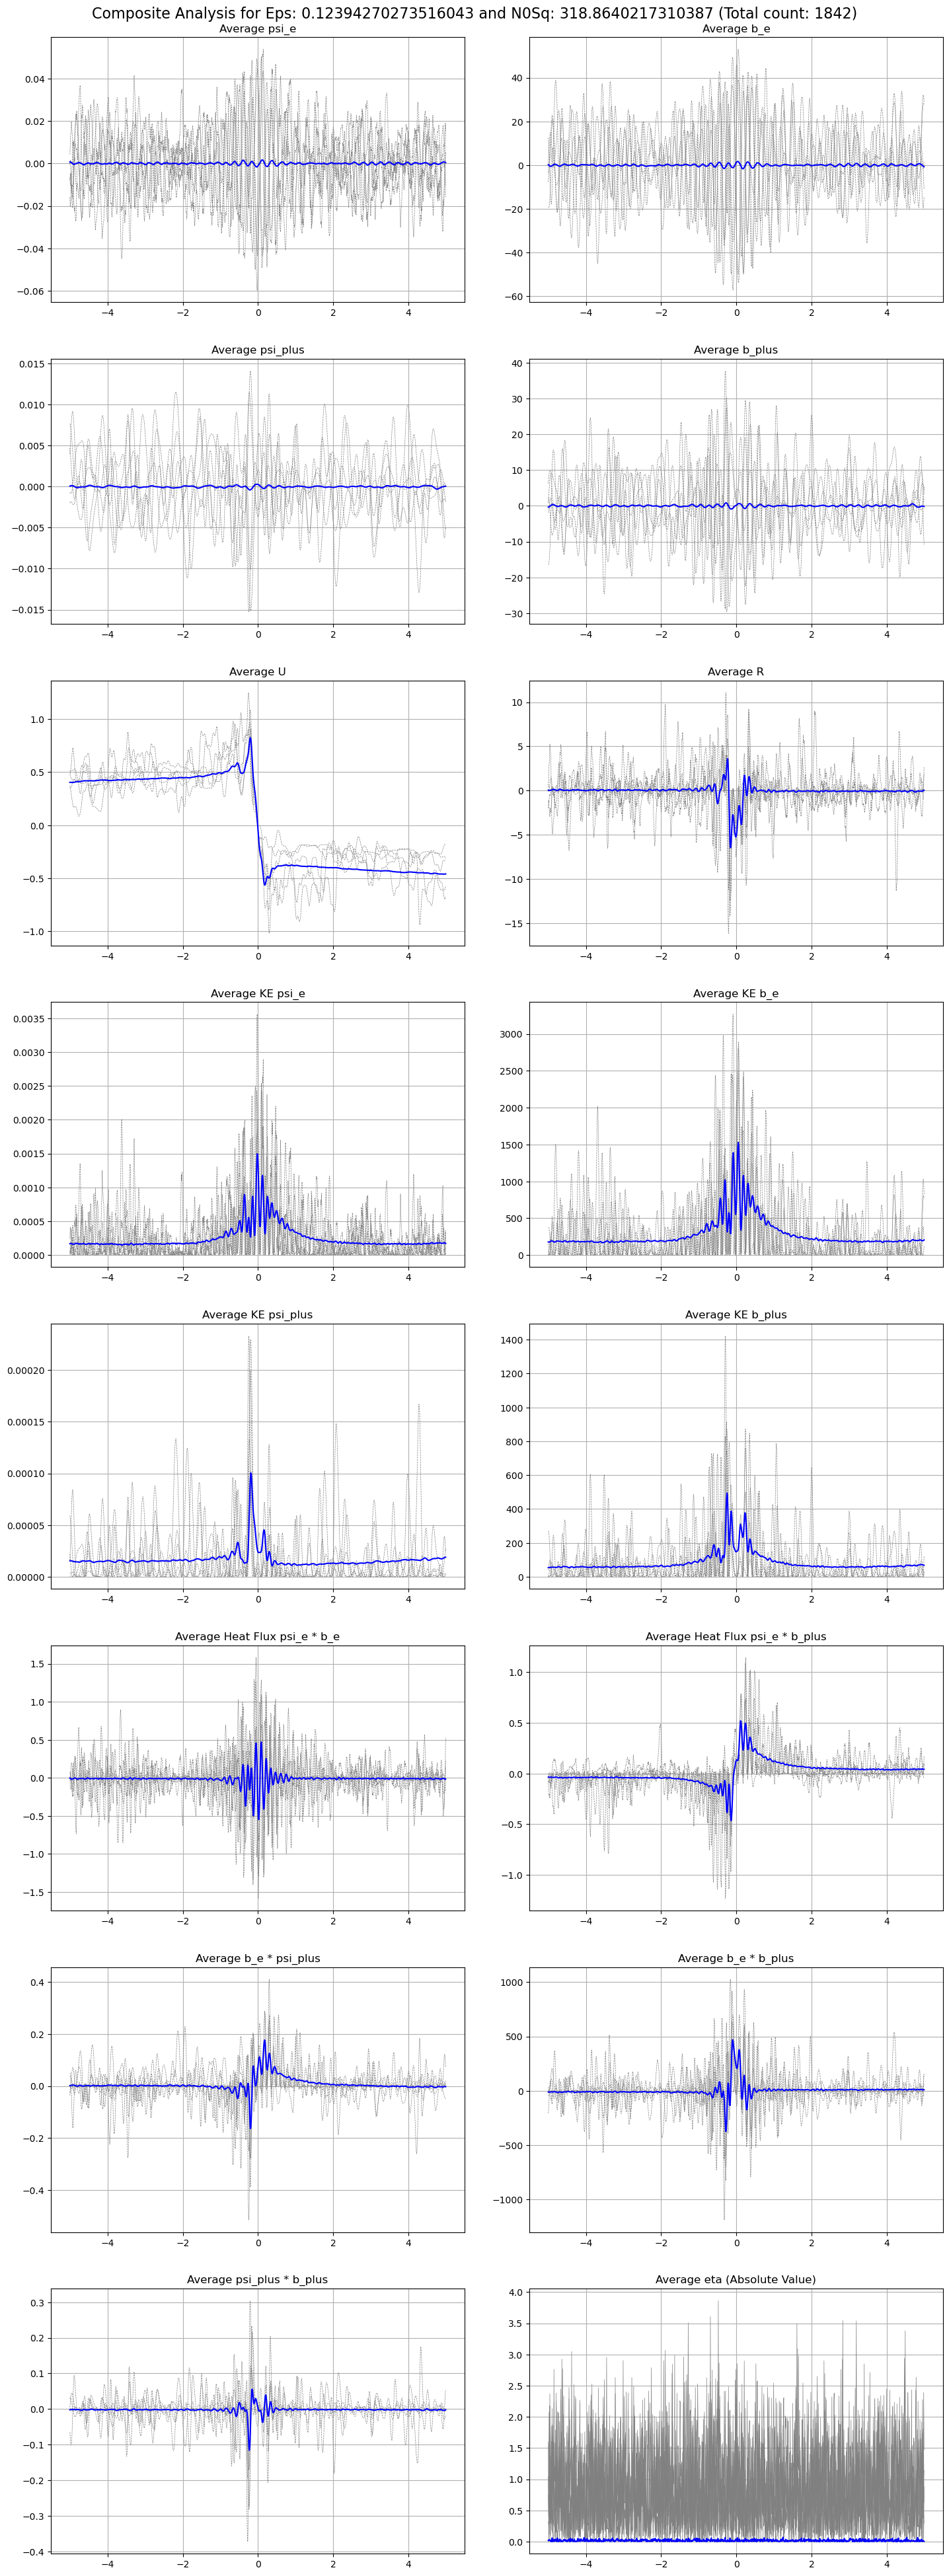

In [49]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(8, 2, figsize=(15, 40))

for i in range(5):
    axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_title(f'Average psi_e')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_title(f'Average b_e')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_title(f'Average psi_plus')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_title(f'Average b_plus')
axs[1, 1].grid()

for i in range(5):
    axs[2, 0].plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 0].plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
axs[2, 0].set_title(f'Average U')
axs[2, 0].grid()

for i in range(5):
    axs[2, 1].plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 1].plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
axs[2, 1].set_title(f'Average R')
axs[2, 1].grid()

for i in range(5):
    axs[3, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 0].set_title(f'Average KE psi_e')
axs[3, 0].grid()

for i in range(5):
    axs[3, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 1].set_title(f'Average KE b_e')
axs[3, 1].grid()

for i in range(5):
    axs[4, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 0].set_title(f'Average KE psi_plus')
axs[4, 0].grid()

for i in range(5):
    axs[4, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 1].set_title(f'Average KE b_plus')
axs[4, 1].grid()

for i in range(5):
    axs[5, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
axs[5, 0].grid()

for i in range(5):
    axs[5, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
axs[5, 1].grid()

for i in range(5):
    axs[6, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 0].set_title(f'Average b_e * psi_plus')
axs[6, 0].grid()

for i in range(5):
    axs[6, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 1].set_title(f'Average b_e * b_plus')
axs[6, 1].grid()

for i in range(5):
    axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[7, 0].set_title(f'Average psi_plus * b_plus')
axs[7, 0].grid()

average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

for i in range(5): #Check if the average eta is the same using randn 
    axs[7, 1].plot(time_array, [abs(i[0]) for i in df['eta_list'][i]], linewidth=0.5, linestyle='-', label=f'eta_list {i}', color = 'gray')
axs[7, 1].plot(time_array, [abs(i[0]) for i in average_eta], label='Average', linewidth=1.5, color='blue')
axs[7, 1].set_title('Average eta (Absolute Value)')
axs[7, 1].grid()


plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))})', fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()

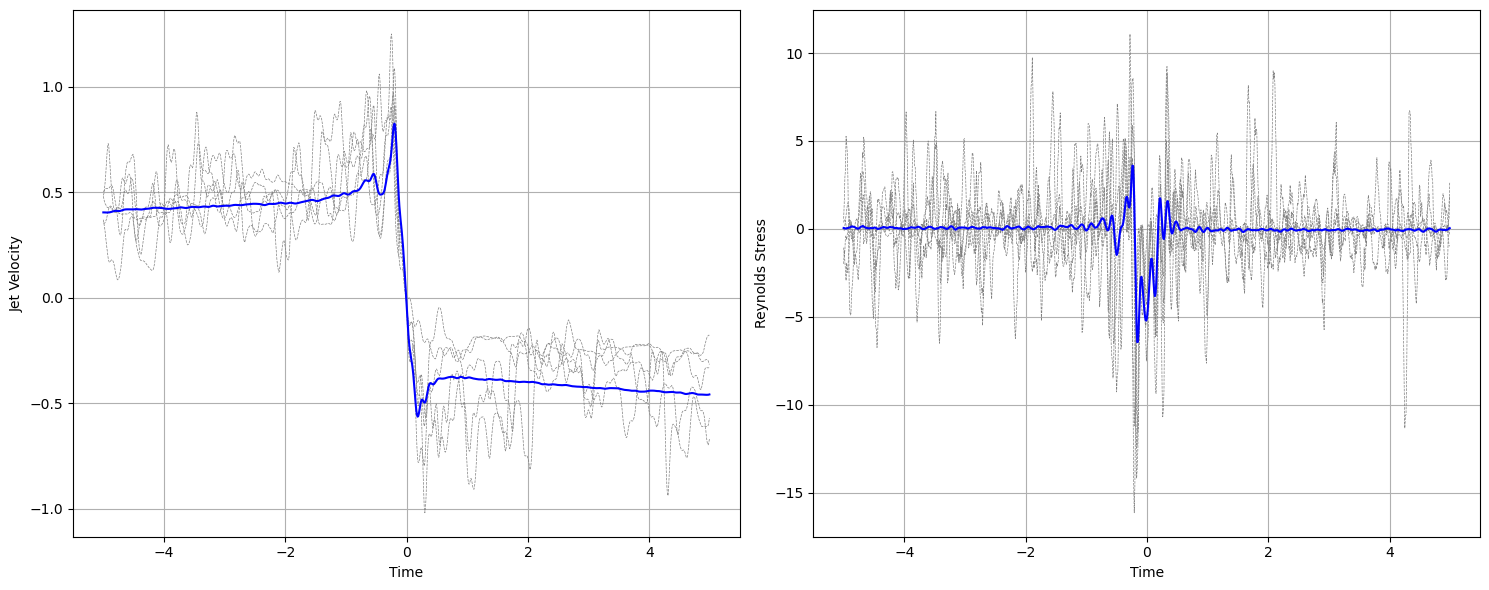

In [50]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# for i in range(5):
#     axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 0].set_title(f'Average psi_e')
# axs[0, 0].grid()


# for i in range(5):
#     axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 1].set_title(f'Average b_e')
# axs[0, 1].grid()

# for i in range(5):
#     axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
# axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 0].set_title(f'Average psi_plus')
# axs[1, 0].grid()

# for i in range(5):
#     axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 1].set_title(f'Average b_plus')
# axs[1, 1].grid()

for i in range(5):
    axs[0].plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0].plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
# axs[0].set_title(f'Average U')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Jet Velocity')
axs[0].grid()

for i in range(5):
    axs[1].plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1].plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
# axs[1].set_title(f'Average R')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Reynolds Stress')
axs[1].grid()

# for i in range(5):
#     axs[3, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 0].set_title(f'Average KE psi_e')
# axs[3, 0].grid()

# for i in range(5):
#     axs[3, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 1].set_title(f'Average KE b_e')
# axs[3, 1].grid()

# for i in range(5):
#     axs[4, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 0].set_title(f'Average KE psi_plus')
# axs[4, 0].grid()

# for i in range(5):
#     axs[4, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 1].set_title(f'Average KE b_plus')
# axs[4, 1].grid()

# for i in range(5):
#     axs[5, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
# axs[5, 0].grid()

# for i in range(5):
#     axs[5, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
# axs[5, 1].grid()

# for i in range(5):
#     axs[6, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 0].set_title(f'Average b_e * psi_plus')
# axs[6, 0].grid()

# for i in range(5):
#     axs[6, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 1].set_title(f'Average b_e * b_plus')
# axs[6, 1].grid()

# for i in range(5):
#     axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[7, 0].set_title(f'Average psi_plus * b_plus')
# axs[7, 0].grid()

# average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

# for i in range(5): #Check if the average eta is the same using randn 
#     axs[7, 1].plot(time_array, [abs(i[0]) for i in df['eta_list'][i]], linewidth=0.5, linestyle='-', label=f'eta_list {i}', color = 'gray')
# axs[7, 1].plot(time_array, [abs(i[0]) for i in average_eta], label='Average', linewidth=1.5, color='blue')
# axs[7, 1].set_title('Average eta (Absolute Value)')
# axs[7, 1].grid()


# plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))})', fontsize=16)
# plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout()

plt.show()

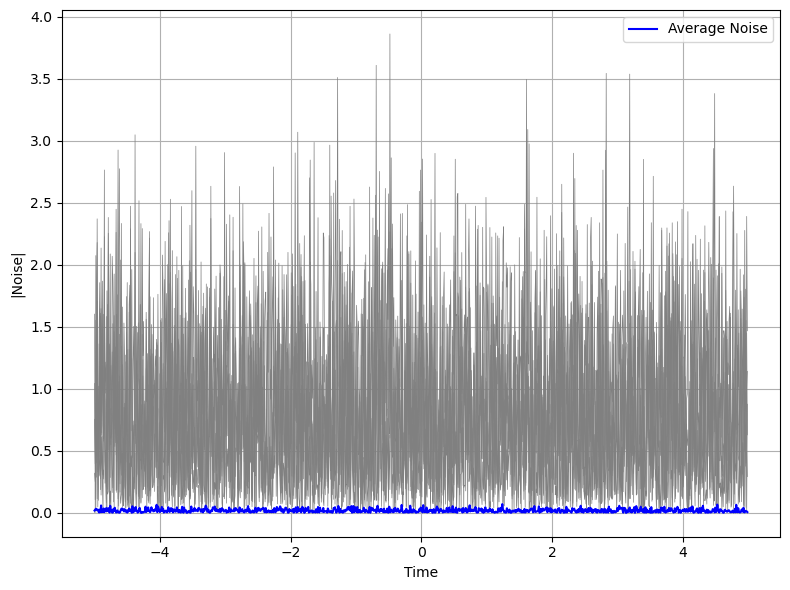

In [51]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(1, 1, figsize=(8,6))

# for i in range(5):
#     axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 0].set_title(f'Average psi_e')
# axs[0, 0].grid()


# for i in range(5):
#     axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 1].set_title(f'Average b_e')
# axs[0, 1].grid()

# for i in range(5):
#     axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
# axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 0].set_title(f'Average psi_plus')
# axs[1, 0].grid()

# for i in range(5):
#     axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 1].set_title(f'Average b_plus')
# axs[1, 1].grid()

# for i in range(5):
#     axs.plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs.plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
# # axs[0].set_title(f'Average U')
# axs.set_xlabel('Time')
# axs.set_ylabel('Jet Velocity')
# axs.grid()



# for i in range(5):
#     axs[3, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 0].set_title(f'Average KE psi_e')
# axs[3, 0].grid()

# for i in range(5):
#     axs[3, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 1].set_title(f'Average KE b_e')
# axs[3, 1].grid()

# for i in range(5):
#     axs[4, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 0].set_title(f'Average KE psi_plus')
# axs[4, 0].grid()

# for i in range(5):
#     axs[4, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 1].set_title(f'Average KE b_plus')
# axs[4, 1].grid()

# for i in range(5):
#     axs[5, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
# axs[5, 0].grid()

# for i in range(5):
#     axs[5, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
# axs[5, 1].grid()

# for i in range(5):
#     axs[6, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 0].set_title(f'Average b_e * psi_plus')
# axs[6, 0].grid()

# for i in range(5):
#     axs[6, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 1].set_title(f'Average b_e * b_plus')
# axs[6, 1].grid()

# for i in range(5):
#     axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[7, 0].set_title(f'Average psi_plus * b_plus')
# axs[7, 0].grid()

average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

for i in range(5): #Check if the average eta is the same using randn 
    axs.plot(time_array, [abs(i[0]) for i in df['eta_list'][i]], linewidth=0.5, linestyle='-', color = 'gray')
axs.plot(time_array, [abs(i[0]) for i in average_eta], label='Average Noise', linewidth=1.5, color='blue')
# axs.set_title('Average eta (Absolute Value)')
axs.set_xlabel('Time')
axs.set_ylabel('|Noise|')
axs.grid()


# plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))})', fontsize=16)
# plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)
plt.legend()
plt.tight_layout()

plt.show()

Verifying the result by splitting

In [52]:
df = df.sample(frac=1).reset_index(drop=True)

half_index = len(df) // 2
df1 = df.iloc[:half_index]
df2 = df.iloc[half_index:]

In [53]:
df1.describe(include='all')

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
count,921.000000,9.210000e+02,9.210000e+02,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921
unique,NaN,NaN,NaN,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921
top,NaN,NaN,NaN,"[0.01047989532413688, 0.015484690365783323, 0....","[23.964075982494567, 20.229680377041138, 15.46...","[0.009170220504541778, 0.010137318907972318, 0...","[-15.887002251479094, -14.797124282249335, -13...","[0.26500884658407353, 0.3066687066978039, 0.36...","[3.2539357993960385, 5.314934186206686, 7.0591...","[0.00010982820600486604, 0.0002397756357241828...","[574.276937694773, 409.23996815724325, 239.269...","[8.409294410191846e-05, 0.00010276523464193308...","[252.3968405385018, 218.9548870243329, 181.251...","[0.25114100783620574, 0.31325033683724485, 0.2...","[-0.16649412060982785, -0.22912888781464474, -...","[0.21975586094706884, 0.2050747213884157, 0.17...","[-380.71732908850726, -299.3410947292583, -208...","[-0.14568731380221497, -0.1500031677700625, -0...","[[0.12029373180531398], [0.15883548765727226],..."
freq,NaN,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
mean,13184.246471,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,537.437826,2.082799e-15,3.981201e-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,12265.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,12719.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,13164.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,13654.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
df2.describe(include='all')

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
count,921.000000,9.210000e+02,9.210000e+02,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921
unique,NaN,NaN,NaN,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921,921
top,NaN,NaN,NaN,"[0.022716910476060698, 0.024668564187900165, 0...","[2.8861238261340776, -2.477905039546871, -7.06...","[0.002943102763023745, 0.0027796450964450493, ...","[0.9446510470061384, 1.5328885829769316, 2.464...","[0.367936217783028, 0.3915957470199072, 0.4100...","[2.263742108881873, 2.3216966670717922, 1.3952...","[0.0005160580215773562, 0.0006085380590925506,...","[8.329710739778807, 6.1400133850117795, 49.982...","[8.661853873718001e-06, 7.726426862191007e-06,...","[0.8923656006097935, 2.3497474078210256, 6.075...","[0.06556381658111361, -0.061126359519583284, -...","[0.02145955326595545, 0.03781416040206577, 0.0...","[0.008494159007123865, -0.006887696592632935, ...","[2.726379894146919, -3.798352344822401, -17.42...","[0.0027802051065370396, 0.0042608862330684285,...","[[0.6924174755622564], [-0.43459286660246244],..."
freq,NaN,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
mean,13184.753529,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,526.563344,2.082799e-15,3.981201e-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,12264.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,12731.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,13206.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,13635.000000,2.000000e-01,5.855556e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Plotting the First Half

In [55]:
df1_average_psi_e = average_arrays(*list(df1['psi_e']))
df1_average_b_e = average_arrays(*list(df1['b_e']))
df1_average_psi_plus = average_arrays(*list(df1['psi_plus']))
df1_average_b_plus = average_arrays(*list(df1['b_plus']))
df1_average_U = average_arrays(*list(df1['u_list']))
df1_average_R = average_arrays(*list(df1['r_list']))
df1_average_k_e_psi_e_list = average_arrays(*list(df1['k_e_psi_e_list']))
df1_average_k_e_b_e_list = average_arrays(*list(df1['k_e_b_e_list']))
df1_average_k_e_psi_plus_list = average_arrays(*list(df1['k_e_psi_plus_list']))
df1_average_k_e_b_plus_list = average_arrays(*list(df1['k_e_b_plus_list']))
df1_average_heat_flux_psi_e_b_e_list = average_arrays(*list(df1['heat_flux_psi_e_b_e_list']))
df1_average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df1['heat_flux_psi_e_b_plus_list']))
df1_average_b_e_psi_plus_list = average_arrays(*list(df1['b_e_psi_plus_list']))
df1_average_b_e_b_plus_list = average_arrays(*list(df1['b_e_b_plus_list']))
df1_average_psi_plus_b_plus_list = average_arrays(*list(df1['psi_plus_b_plus_list']))
df1_average_eta = average_arrays(*list(df1['eta_list']))

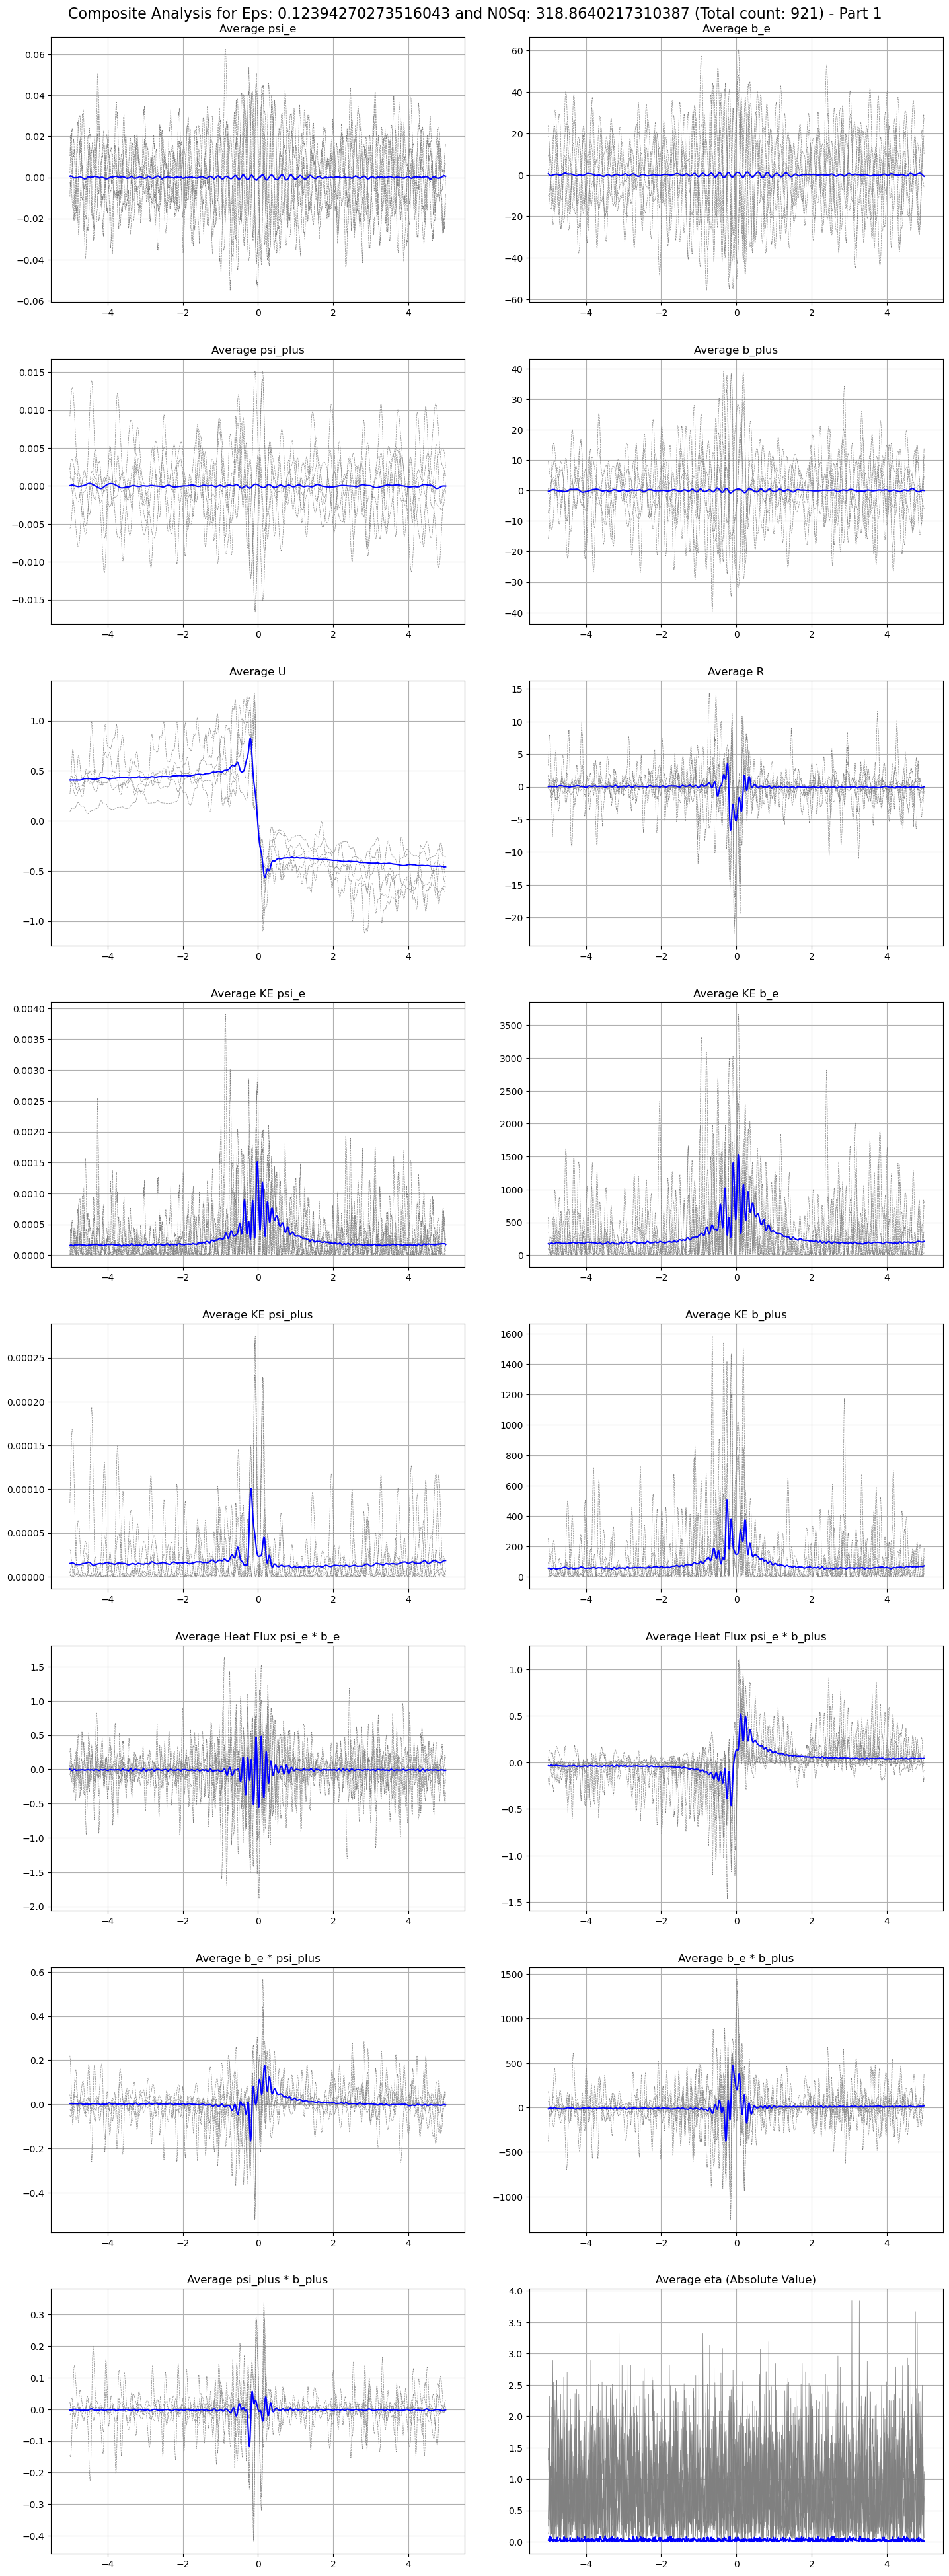

In [56]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(8, 2, figsize=(15, 40))

for i in range(5):
    axs[0, 0].plot(time_array, df1['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, df1_average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_title(f'Average psi_e')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df1['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, df1_average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_title(f'Average b_e')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df1['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, df1_average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_title(f'Average psi_plus')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df1['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, df1_average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_title(f'Average b_plus')
axs[1, 1].grid()

for i in range(5):
    axs[2, 0].plot(time_array, df1['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 0].plot(time_array, df1_average_U, label='Average', linewidth=1.5, color='blue')
axs[2, 0].set_title(f'Average U')
axs[2, 0].grid()

for i in range(5):
    axs[2, 1].plot(time_array, df1['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 1].plot(time_array, df1_average_R, label='Average', linewidth=1.5, color='blue')
axs[2, 1].set_title(f'Average R')
axs[2, 1].grid()

for i in range(5):
    axs[3, 0].plot(time_array, df1['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 0].plot(time_array, df1_average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 0].set_title(f'Average KE psi_e')
axs[3, 0].grid()

for i in range(5):
    axs[3, 1].plot(time_array, df1['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 1].plot(time_array, df1_average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 1].set_title(f'Average KE b_e')
axs[3, 1].grid()

for i in range(5):
    axs[4, 0].plot(time_array, df1['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 0].plot(time_array, df1_average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 0].set_title(f'Average KE psi_plus')
axs[4, 0].grid()

for i in range(5):
    axs[4, 1].plot(time_array, df1['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 1].plot(time_array, df1_average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 1].set_title(f'Average KE b_plus')
axs[4, 1].grid()

for i in range(5):
    axs[5, 0].plot(time_array, df1['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 0].plot(time_array, df1_average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
axs[5, 0].grid()

for i in range(5):
    axs[5, 1].plot(time_array, df1['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 1].plot(time_array, df1_average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
axs[5, 1].grid()

for i in range(5):
    axs[6, 0].plot(time_array, df1['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 0].plot(time_array, df1_average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 0].set_title(f'Average b_e * psi_plus')
axs[6, 0].grid()

for i in range(5):
    axs[6, 1].plot(time_array, df1['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 1].plot(time_array, df1_average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 1].set_title(f'Average b_e * b_plus')
axs[6, 1].grid()

for i in range(5):
    axs[7, 0].plot(time_array, df1['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[7, 0].plot(time_array, df1_average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[7, 0].set_title(f'Average psi_plus * b_plus')
axs[7, 0].grid()


for i in range(5):
    axs[7, 1].plot(time_array, [abs(i[0]) for i in df1['eta_list'][i]], linewidth=0.5, linestyle='-', label=f'eta_list {i}', color = 'gray')
axs[7, 1].plot(time_array, [abs(i[0]) for i in df1_average_eta], label='Average', linewidth=1.5, color='blue')
axs[7, 1].set_title('Average eta (Absolute Value)')
axs[7, 1].grid()


plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df1['b_e']))}) - Part 1', fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()

Plotting the Second Half

In [57]:
df2.reset_index(drop=True, inplace = True)

In [58]:
df2_average_psi_e = average_arrays(*list(df2['psi_e']))
df2_average_b_e = average_arrays(*list(df2['b_e']))
df2_average_psi_plus = average_arrays(*list(df2['psi_plus']))
df2_average_b_plus = average_arrays(*list(df2['b_plus']))
df2_average_U = average_arrays(*list(df2['u_list']))
df2_average_R = average_arrays(*list(df2['r_list']))
df2_average_k_e_psi_e_list = average_arrays(*list(df2['k_e_psi_e_list']))
df2_average_k_e_b_e_list = average_arrays(*list(df2['k_e_b_e_list']))
df2_average_k_e_psi_plus_list = average_arrays(*list(df2['k_e_psi_plus_list']))
df2_average_k_e_b_plus_list = average_arrays(*list(df2['k_e_b_plus_list']))
df2_average_heat_flux_psi_e_b_e_list = average_arrays(*list(df2['heat_flux_psi_e_b_e_list']))
df2_average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df2['heat_flux_psi_e_b_plus_list']))
df2_average_b_e_psi_plus_list = average_arrays(*list(df2['b_e_psi_plus_list']))
df2_average_b_e_b_plus_list = average_arrays(*list(df2['b_e_b_plus_list']))
df2_average_psi_plus_b_plus_list = average_arrays(*list(df2['psi_plus_b_plus_list']))
df2_average_eta = average_arrays(*list(df2['eta_list']))

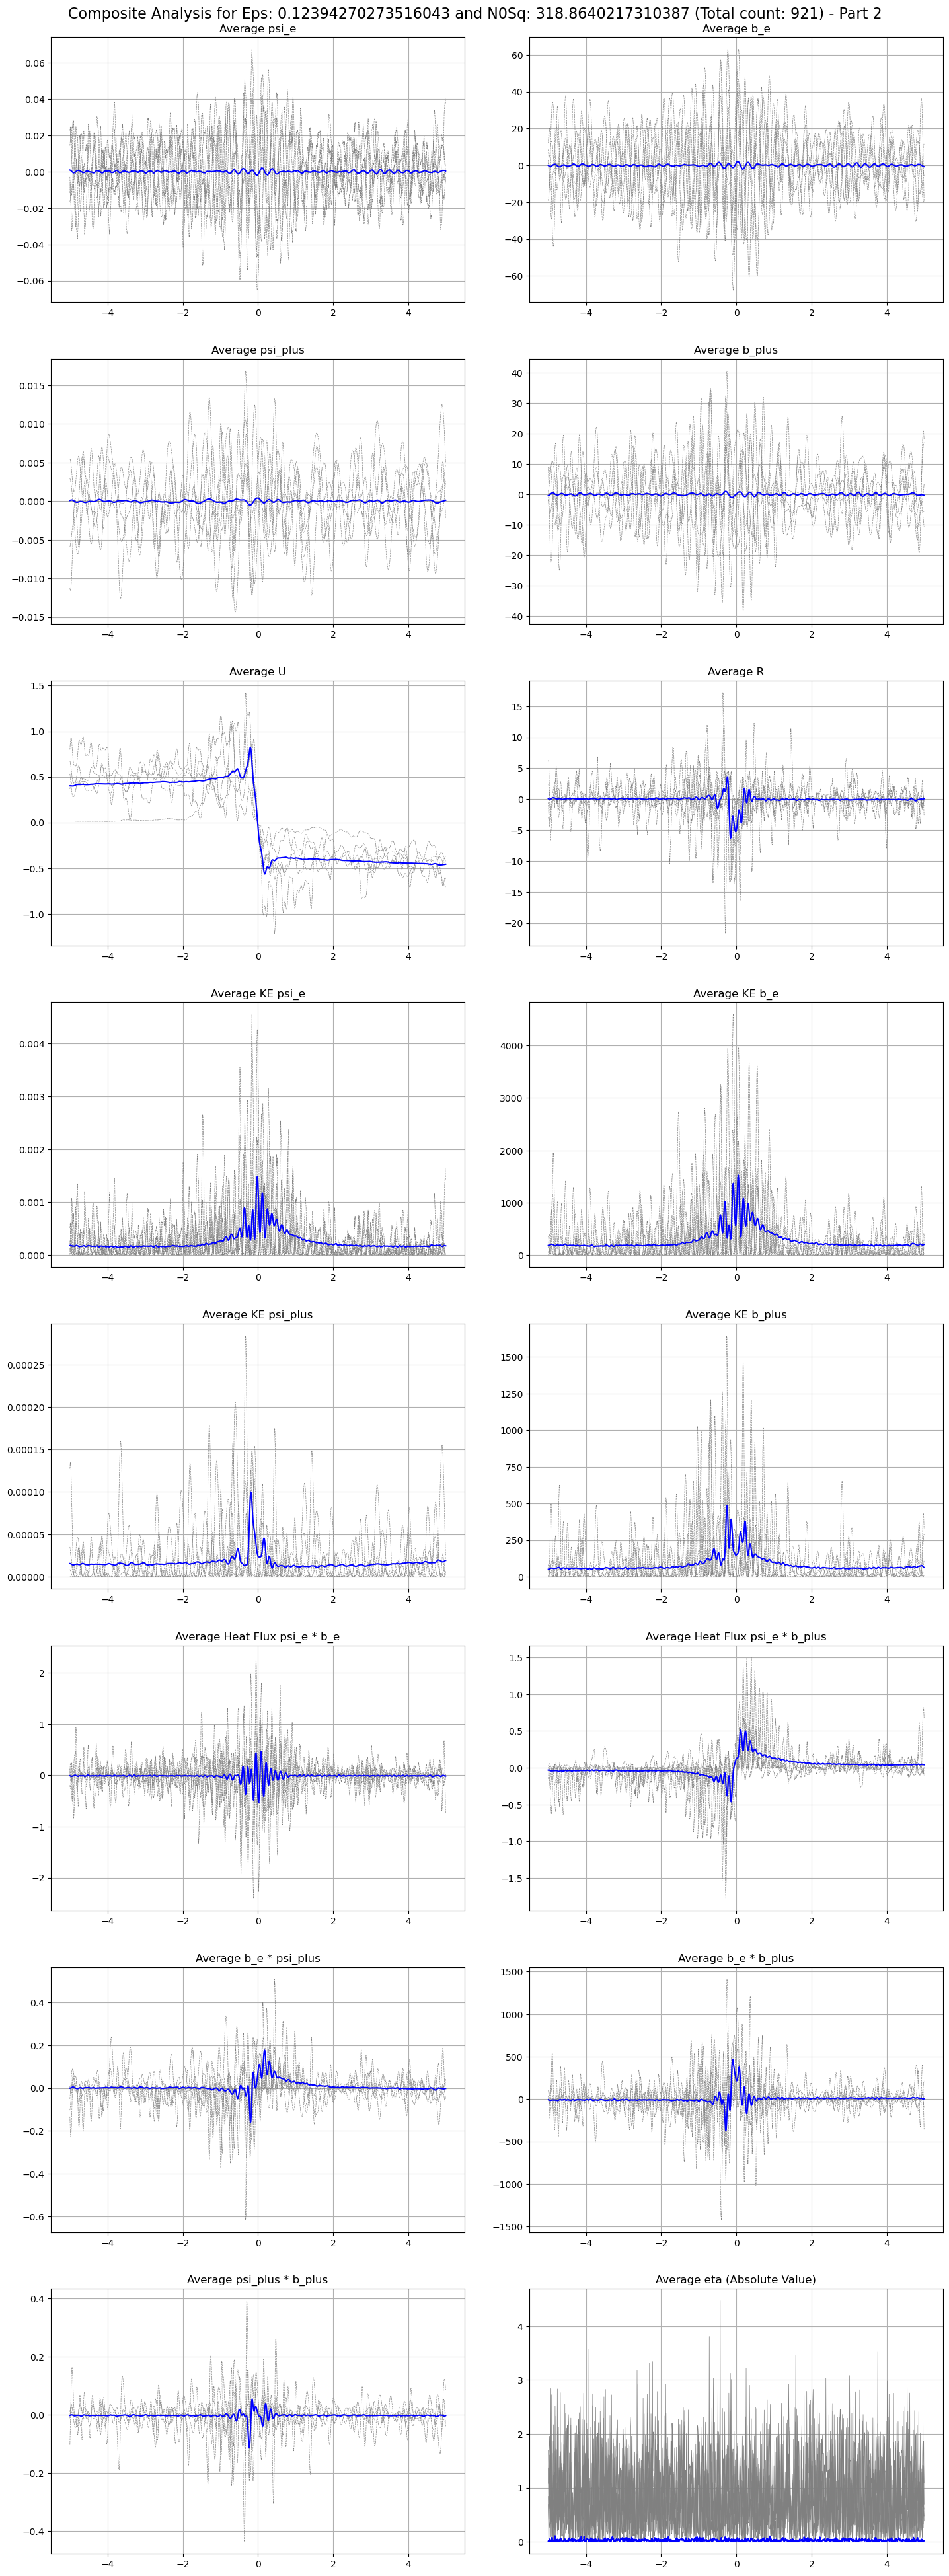

In [59]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(8, 2, figsize=(15, 40))

for i in range(5):
    axs[0, 0].plot(time_array, df2['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, df2_average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_title(f'Average psi_e')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df2['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, df2_average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_title(f'Average b_e')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df2['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, df2_average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_title(f'Average psi_plus')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df2['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, df2_average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_title(f'Average b_plus')
axs[1, 1].grid()

for i in range(5):
    axs[2, 0].plot(time_array, df2['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 0].plot(time_array, df2_average_U, label='Average', linewidth=1.5, color='blue')
axs[2, 0].set_title(f'Average U')
axs[2, 0].grid()

for i in range(5):
    axs[2, 1].plot(time_array, df2['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 1].plot(time_array, df2_average_R, label='Average', linewidth=1.5, color='blue')
axs[2, 1].set_title(f'Average R')
axs[2, 1].grid()

for i in range(5):
    axs[3, 0].plot(time_array, df2['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 0].plot(time_array, df2_average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 0].set_title(f'Average KE psi_e')
axs[3, 0].grid()

for i in range(5):
    axs[3, 1].plot(time_array, df2['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 1].plot(time_array, df2_average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 1].set_title(f'Average KE b_e')
axs[3, 1].grid()

for i in range(5):
    axs[4, 0].plot(time_array, df2['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 0].plot(time_array, df2_average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 0].set_title(f'Average KE psi_plus')
axs[4, 0].grid()

for i in range(5):
    axs[4, 1].plot(time_array, df2['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 1].plot(time_array, df2_average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 1].set_title(f'Average KE b_plus')
axs[4, 1].grid()

for i in range(5):
    axs[5, 0].plot(time_array, df2['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 0].plot(time_array, df2_average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
axs[5, 0].grid()

for i in range(5):
    axs[5, 1].plot(time_array, df2['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 1].plot(time_array, df2_average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
axs[5, 1].grid()

for i in range(5):
    axs[6, 0].plot(time_array, df2['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 0].plot(time_array, df2_average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 0].set_title(f'Average b_e * psi_plus')
axs[6, 0].grid()

for i in range(5):
    axs[6, 1].plot(time_array, df2['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 1].plot(time_array, df2_average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 1].set_title(f'Average b_e * b_plus')
axs[6, 1].grid()

for i in range(5):
    axs[7, 0].plot(time_array, df2['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[7, 0].plot(time_array, df2_average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[7, 0].set_title(f'Average psi_plus * b_plus')
axs[7, 0].grid()

average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

for i in range(5):
    axs[7, 1].plot(time_array, [abs(i[0]) for i in df2['eta_list'][i]], linewidth=0.5, linestyle='-', label=f'eta_list {i}', color = 'gray')
axs[7, 1].plot(time_array, [abs(i[0]) for i in df2_average_eta], label='Average', linewidth=1.5, color='blue')
axs[7, 1].set_title('Average eta (Absolute Value)')
axs[7, 1].grid()


plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df2['b_e']))}) - Part 2', fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()

Plotting the composites on the same axes

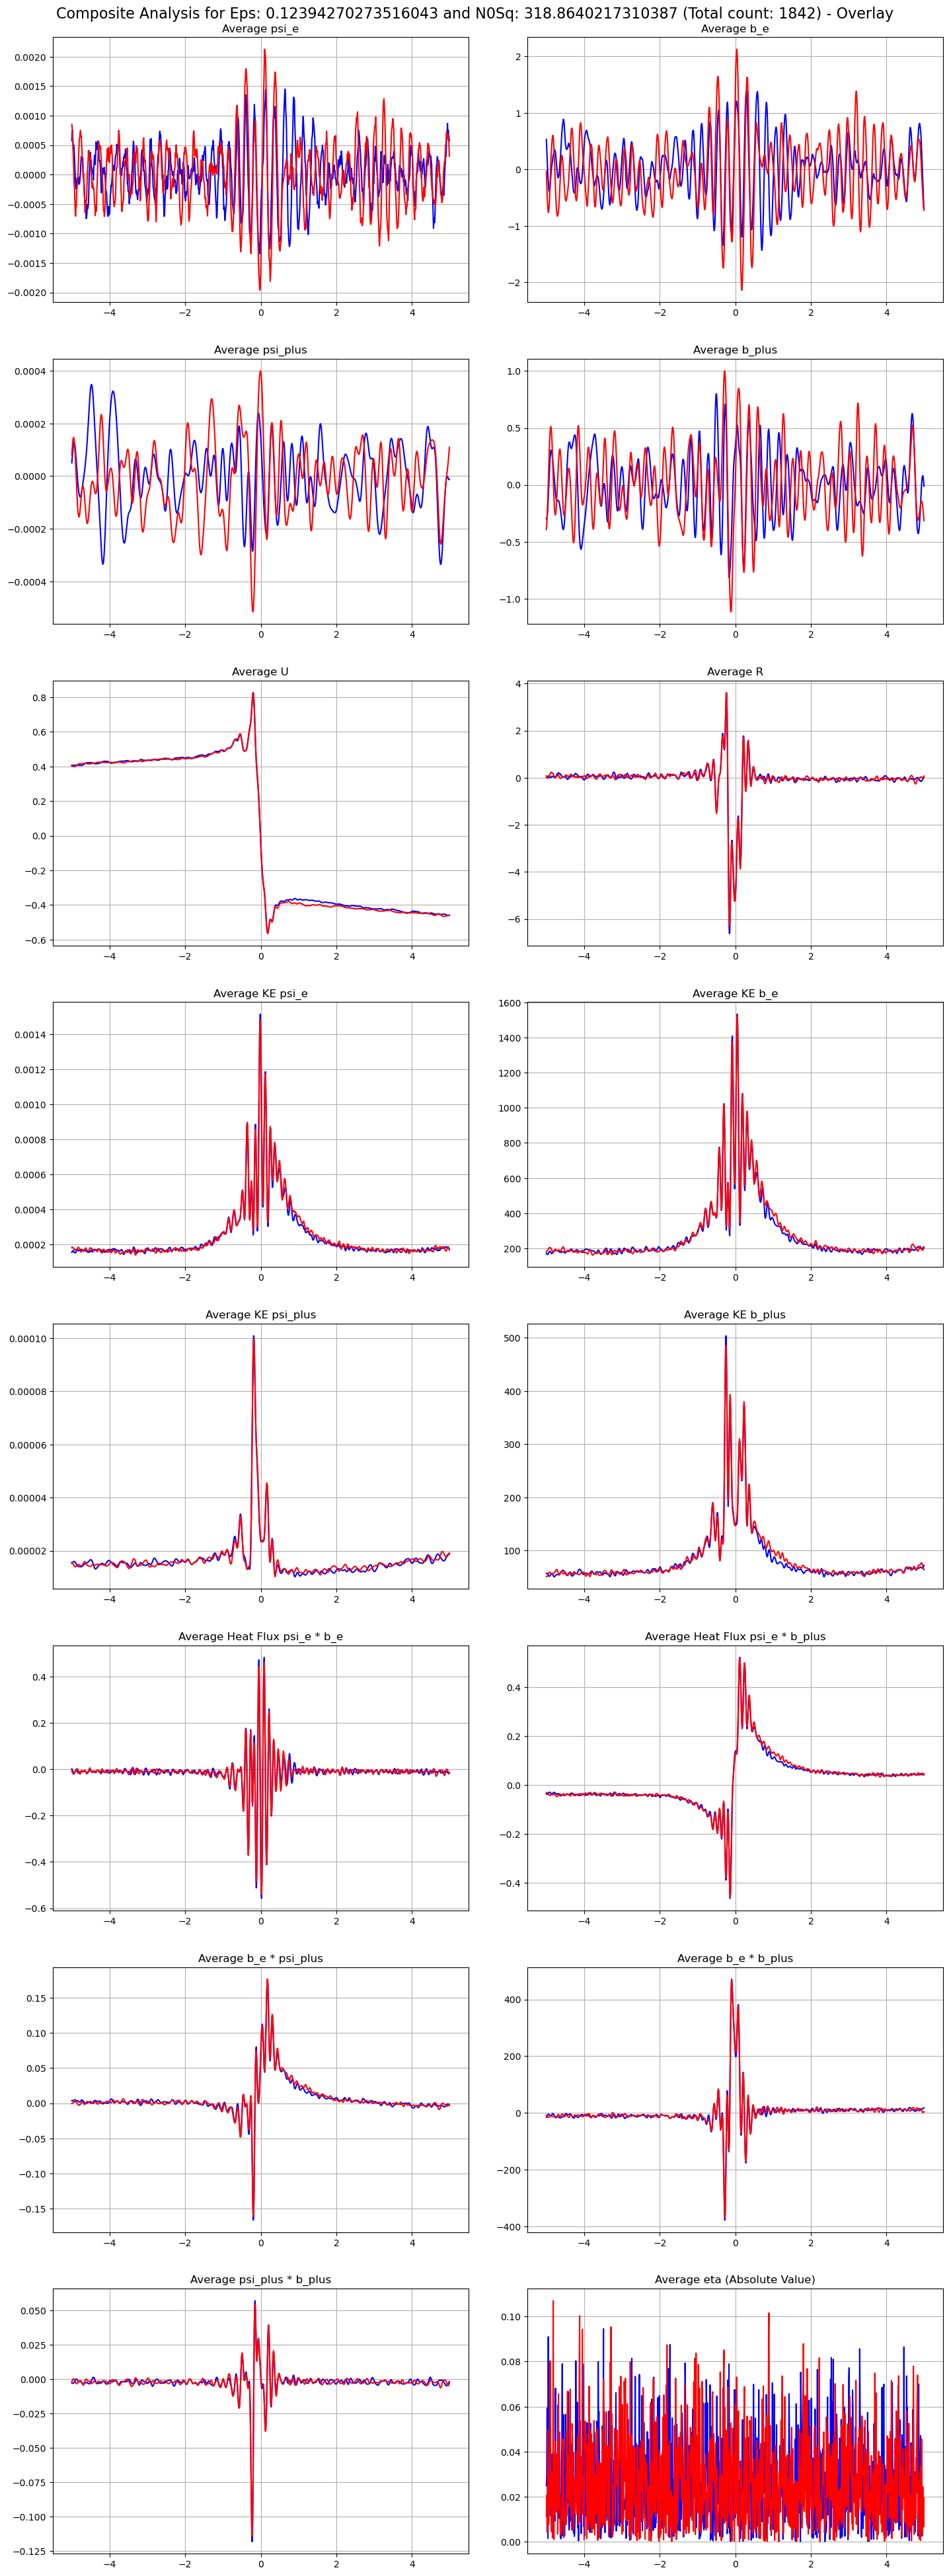

In [60]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(8, 2, figsize=(15, 40))

axs[0, 0].plot(time_array, df1_average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].plot(time_array, df2_average_psi_e, label='Average', linewidth=1.5, color='red')
axs[0, 0].set_title(f'Average psi_e')
axs[0, 0].grid()


axs[0, 1].plot(time_array, df1_average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].plot(time_array, df2_average_b_e, label='Average', linewidth=1.5, color='red')
axs[0, 1].set_title(f'Average b_e')
axs[0, 1].grid()

axs[1, 0].plot(time_array, df1_average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].plot(time_array, df2_average_psi_plus, label='Average', linewidth=1.5, color='red')
axs[1, 0].set_title(f'Average psi_plus')
axs[1, 0].grid()

axs[1, 1].plot(time_array, df1_average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].plot(time_array, df2_average_b_plus, label='Average', linewidth=1.5, color='red')
axs[1, 1].set_title(f'Average b_plus')
axs[1, 1].grid()

axs[2, 0].plot(time_array, df1_average_U, label='Average', linewidth=1.5, color='blue')
axs[2, 0].plot(time_array, df2_average_U, label='Average', linewidth=1.5, color='red')
axs[2, 0].set_title(f'Average U')
axs[2, 0].grid()

axs[2, 1].plot(time_array, df1_average_R, label='Average', linewidth=1.5, color='blue')
axs[2, 1].plot(time_array, df2_average_R, label='Average', linewidth=1.5, color='red')
axs[2, 1].set_title(f'Average R')
axs[2, 1].grid()

axs[3, 0].plot(time_array, df1_average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 0].plot(time_array, df2_average_k_e_psi_e_list, label='Average', linewidth=1.5, color='red')
axs[3, 0].set_title(f'Average KE psi_e')
axs[3, 0].grid()

axs[3, 1].plot(time_array, df1_average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 1].plot(time_array, df2_average_k_e_b_e_list, label='Average', linewidth=1.5, color='red')
axs[3, 1].set_title(f'Average KE b_e')
axs[3, 1].grid()

axs[4, 0].plot(time_array, df1_average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 0].plot(time_array, df2_average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='red')
axs[4, 0].set_title(f'Average KE psi_plus')
axs[4, 0].grid()

axs[4, 1].plot(time_array, df1_average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 1].plot(time_array, df2_average_k_e_b_plus_list, label='Average', linewidth=1.5, color='red')
axs[4, 1].set_title(f'Average KE b_plus')
axs[4, 1].grid()

axs[5, 0].plot(time_array, df1_average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[5, 0].plot(time_array, df2_average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='red')
axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
axs[5, 0].grid()

axs[5, 1].plot(time_array, df1_average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[5, 1].plot(time_array, df2_average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='red')
axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
axs[5, 1].grid()

axs[6, 0].plot(time_array, df1_average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 0].plot(time_array, df2_average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='red')
axs[6, 0].set_title(f'Average b_e * psi_plus')
axs[6, 0].grid()

axs[6, 1].plot(time_array, df1_average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 1].plot(time_array, df2_average_b_e_b_plus_list, label='Average', linewidth=1.5, color='red')
axs[6, 1].set_title(f'Average b_e * b_plus')
axs[6, 1].grid()

axs[7, 0].plot(time_array, df1_average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[7, 0].plot(time_array, df2_average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='red')
axs[7, 0].set_title(f'Average psi_plus * b_plus')
axs[7, 0].grid()

average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

axs[7, 1].plot(time_array, [abs(i[0]) for i in df1_average_eta], label='Average', linewidth=1.5, color='blue')
axs[7, 1].plot(time_array, [abs(i[0]) for i in df2_average_eta], label='Average', linewidth=1.5, color='red')
axs[7, 1].set_title('Average eta (Absolute Value)')
axs[7, 1].grid()


plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))}) - Overlay', fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()

In [62]:
# ==== Build phi_e_list / phi_plus_list / U_list / R_list from your DataFrame and run diagnostics ====

import json
import numpy as np

# --- 1) Helpers to decode JSON-ish columns safely into numpy arrays ---

def _to_1d_array(x):
    """Turn a DB/pandas cell (list or json-string) into a 1D np.array of floats."""
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except Exception:
            # If it's a Python-list-as-string, try eval as last resort
            x = eval(x)
    return np.asarray(x, dtype=float)

def _stack_psi_b(psi, b):
    """Stack psi and b into shape [T, 2]."""
    psi = _to_1d_array(psi)
    b   = _to_1d_array(b)
    if len(psi) != len(b):
        raise ValueError("psi and b lengths differ in a row. Data is inconsistent.")
    return np.stack([psi, b], axis=1)

# --- 2) Extract lists from df row-by-row ---

phi_e_list, phi_plus_list, U_list, R_list = [], [], [], []

for idx, row in df.iterrows():
    try:
        phi_e_list.append(_stack_psi_b(row["psi_e"],   row["b_e"]))
        phi_plus_list.append(_stack_psi_b(row["psi_plus"], row["b_plus"]))
        U_list.append(_to_1d_array(row["u_list"]))
        R_list.append(_to_1d_array(row["r_list"]))
    except KeyError as e:
        raise KeyError(f"Missing column in DataFrame: {e}. Expected columns: "
                       "'psi_e', 'b_e', 'psi_plus', 'b_plus', 'u_list', 'r_list'.")

# --- 3) Force a common time window length across all series (trim to min length) ---

def _min_len(*list_groups):
    return min(min(len(arr) for arr in L) for L in list_groups)

Tmin = _min_len(
    [x[:, 0] for x in phi_e_list],
    [x[:, 0] for x in phi_plus_list],
    U_list, R_list
)

phi_e_list   = [x[:Tmin] for x in phi_e_list]
phi_plus_list= [x[:Tmin] for x in phi_plus_list]
U_list       = [x[:Tmin] for x in U_list]
R_list       = [x[:Tmin] for x in R_list]

print(f"Prepared {len(phi_e_list)} reversal windows with common length T={Tmin}")

# --- 4) Time step. Set this to whatever you used in the simulation (your script had dt=0.001) ---
dt = 0.001  # <-- change if you used something else

# --- 5) Drop-in diagnostics (same API you saw earlier). If you already defined these, skip redefining. ---

import os
import matplotlib.pyplot as plt

def _ensure_same_lengths(*lists):
    Ts = []
    for L in lists:
        if not L:
            raise ValueError("One of the provided lists is empty.")
        Ts.append([len(arr) for arr in L])
    for tvec in Ts:
        if len(set(tvec)) != 1:
            raise ValueError("Not all time windows have the same length within one of the lists.")
    baseT = len(lists[0][0])
    for L in lists[1:]:
        if len(L[0]) != baseT:
            raise ValueError("Time window length mismatch across provided lists.")

def _stack_ensemble(series_list):
    K = len(series_list); T = len(series_list[0])
    out = np.zeros((K, T))
    for k, s in enumerate(series_list):
        out[k, :] = s
    return out

def compute_alignment_indices(phi_e_list, phi_plus_list):
    _ensure_same_lengths(phi_e_list, phi_plus_list)
    psi_e = _stack_ensemble([arr[:, 0] for arr in phi_e_list])
    psi_p = _stack_ensemble([arr[:, 0] for arr in phi_plus_list])
    r = psi_e * psi_p
    signs = np.sign(r)
    A0 = np.mean(signs, axis=0)
    numerator = np.sum(r, axis=0)
    denom = np.sum(np.abs(r), axis=0)
    Aw = np.zeros_like(numerator)
    mask = denom > 0
    Aw[mask] = numerator[mask] / denom[mask]
    s_e = np.sign(psi_e); s_p = np.sign(psi_p)
    Q2 = (s_e < 0) & (s_p > 0)
    Q4 = (s_e > 0) & (s_p < 0)
    frac_Q2 = np.mean(Q2, axis=0)
    frac_Q4 = np.mean(Q4, axis=0)
    frac_Q2Q4 = frac_Q2 + frac_Q4
    R_ensemble = np.mean(r, axis=0)
    return {"A0": A0, "Aw": Aw, "R_ensemble": R_ensemble,
            "frac_Q2": frac_Q2, "frac_Q4": frac_Q4, "frac_Q2Q4": frac_Q2Q4}

def compute_phase_lock_index(phi_e_list, phi_plus_list):
    _ensure_same_lengths(phi_e_list, phi_plus_list)
    psi_e = _stack_ensemble([arr[:, 0] for arr in phi_e_list])
    psi_p = _stack_ensemble([arr[:, 0] for arr in phi_plus_list])
    se = np.sign(psi_e); sp = np.sign(psi_p)
    return np.abs(np.mean(se * sp, axis=0))

def compute_adverse_flux_integral(U_list, R_list, dt):
    _ensure_same_lengths(U_list, R_list)
    U = _stack_ensemble(U_list)
    R = _stack_ensemble(R_list)
    adverse = np.where(U * R < 0, np.abs(R), 0.0)
    adverse_mean = np.mean(adverse, axis=0)
    adverse_cumint = np.cumsum(adverse_mean) * dt
    return {"adverse_mean": adverse_mean, "adverse_cumint": adverse_cumint}

def compute_cumulative_contribution_curves(phi_e_list, phi_plus_list, snapshot_indices):
    _ensure_same_lengths(phi_e_list, phi_plus_list)
    psi_e = _stack_ensemble([arr[:, 0] for arr in phi_e_list])
    psi_p = _stack_ensemble([arr[:, 0] for arr in phi_plus_list])
    r = psi_e * psi_p
    out = {}
    for t in snapshot_indices:
        r_t = r[:, t]
        order = np.argsort(np.abs(r_t))
        sorted_abs = np.abs(r_t)[order]
        denom = np.sum(sorted_abs)
        cum_signed = np.zeros_like(sorted_abs) if denom == 0 else np.cumsum(r_t[order]) / denom
        out[t] = (sorted_abs, cum_signed)
    return out

def make_time_axis(T, dt):
    return (np.arange(T) - T // 2) * dt

def _plot_series(y, t, title, outdir, fname):
    os.makedirs(outdir, exist_ok=True)
    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.title(title); plt.xlabel("time"); plt.ylabel(title)
    path = os.path.join(outdir, fname)
    plt.tight_layout(); plt.savefig(path); plt.close()
    return path

def _plot_multiple_series(series, t, title, outdir, fname):
    os.makedirs(outdir, exist_ok=True)
    plt.figure(figsize=(10, 4))
    for label, arr in series.items():
        plt.plot(t, arr, label=label)
    plt.title(title); plt.xlabel("time"); plt.legend()
    path = os.path.join(outdir, fname)
    plt.tight_layout(); plt.savefig(path); plt.close()
    return path

def _plot_cumulative_curve(sorted_abs, cum_signed, title, outdir, fname):
    os.makedirs(outdir, exist_ok=True)
    K = len(sorted_abs)
    x = np.arange(1, K + 1) / K if K > 0 else np.array([0.0])
    plt.figure(figsize=(6, 4))
    plt.plot(x, cum_signed if K > 0 else np.array([0.0]))
    plt.title(title); plt.xlabel("fraction of eddies (sorted by |r|)"); plt.ylabel("cumulative signed contribution")
    path = os.path.join(outdir, fname)
    plt.tight_layout(); plt.savefig(path); plt.close()
    return path

def visualize_alignment_suite(phi_e_list, phi_plus_list, U_list, R_list, dt, outdir="alignment_plots"):
    _ensure_same_lengths(phi_e_list, phi_plus_list, U_list, R_list)
    T = len(phi_e_list[0]); t = make_time_axis(T, dt); paths = {}
    metrics = compute_alignment_indices(phi_e_list, phi_plus_list)
    paths["A0_Aw_R"] = _plot_multiple_series(
        {"A0 (unweighted alignment)": metrics["A0"],
         "Aw (energy-weighted alignment)": metrics["Aw"],
         "R_ensemble (proxy)": metrics["R_ensemble"]},
        t, "Alignment indices and R_ensemble", outdir, "alignment_indices_and_R.png")
    paths["quadrants"] = _plot_multiple_series(
        {"frac_Q2": metrics["frac_Q2"], "frac_Q4": metrics["frac_Q4"], "frac_Q2+Q4": metrics["frac_Q2Q4"]},
        t, "Quadrant fractions (momentum-transporting quadrants)", outdir, "quadrant_fractions.png")
    Rphi = compute_phase_lock_index(phi_e_list, phi_plus_list)
    paths["phase_lock"] = _plot_series(Rphi, t, "Phase-lock index (sign-correlation proxy)", outdir, "phase_lock_proxy.png")
    adverse = compute_adverse_flux_integral(U_list, R_list, dt)
    paths["adverse_flux"] = _plot_multiple_series(
        {"adverse_flux_mean": adverse["adverse_mean"], "adverse_flux_cumint": adverse["adverse_cumint"]},
        t, "Adverse flux: instantaneous and cumulative", outdir, "adverse_flux.png")
    snapshots = [T // 2 - T // 4, T // 2, T // 2 + T // 4]
    cumcurves = compute_cumulative_contribution_curves(phi_e_list, phi_plus_list, snapshots)
    for s in snapshots:
        sorted_abs, cum_signed = cumcurves[s]
        paths[f"cumcurve_{s}"] = _plot_cumulative_curve(
            sorted_abs, cum_signed, f"Cumulative contribution curve at t ~ {t[s]:.3f}",
            outdir, f"cumulative_contribution_t{s}.png")
    return paths

# --- 6) Run the suite on your DB-loaded data ---

paths = visualize_alignment_suite(phi_e_list, phi_plus_list, U_list, R_list, dt, outdir="alignment_plots_db")
print("Saved figures:")
for k, p in paths.items():
    print(f"{k}: {p}")


Prepared 1842 reversal windows with common length T=1000
Saved figures:
A0_Aw_R: alignment_plots_db/alignment_indices_and_R.png
quadrants: alignment_plots_db/quadrant_fractions.png
phase_lock: alignment_plots_db/phase_lock_proxy.png
adverse_flux: alignment_plots_db/adverse_flux.png
cumcurve_250: alignment_plots_db/cumulative_contribution_t250.png
cumcurve_500: alignment_plots_db/cumulative_contribution_t500.png
cumcurve_750: alignment_plots_db/cumulative_contribution_t750.png
